# 2_01 — Does the MEROPS window score predict measured cleavage kinetics?

## Scope

This is validation A of the specification: whether the specificity matrices
carry information about how fast a bond is actually hydrolysed, or only about
which bonds have been observed to be hydrolysed at all.

The notebook answers that question at the level of the panel. Whether an
individual protease can be accepted is decided in
`2_02_holdout_baseline.ipynb`, which applies one battery of tests to
each of them.

## The two quantities being compared

### The masked MEROPS window score $S^{M}$

For a substrate and a protease, every subsite of the cleavage window
contributes the log-odds of seeing the residue that is there, against seeing it
by chance:

$$S^{M,\mathrm{masked}}_{\pi} = \sum_{p:\,m_p=1} \left( M_{\pi,p,a_p} - \log q_{a_p} \right)$$

* $M_{\pi,p,a}$ is the MEROPS log-probability of residue $a$ at subsite $p$ for
  protease $\pi$: what that enzyme was observed to cleave.
* $q_a$ is the frequency of residue $a$ in the human proteome: what would be
  there anyway.
* $m_p$ marks the subsites the substrate actually populates. A chromogenic
  substrate has a reporter group where the prime side would be, so only
  $P_4 \ldots P_1$ contribute and absent subsites add nothing.

### How a score is built, term by term

Each subsite contributes the logarithm of one ratio:

$$\frac{\Pr(\text{residue } a \text{ at subsite } p \mid \text{this protease cleaved})}
       {\Pr(\text{residue } a \text{ anywhere in the proteome})}$$

The numerator is what MEROPS recorded, the denominator is what would be there
by chance. A ratio above one means the residue is enriched at that subsite among
the cleavages of this enzyme; below one means it is depleted.

The contributions are added, which is the same as multiplying the ratios, so the
total is the log of the overall enrichment of the whole window.

### Units and sign

The units are nats of log-odds, and $e^{S^M}$ is the enrichment as a plain
multiplier.

* $S^M = 0$ — the window looks like an average stretch of proteome. The matrix
  has no opinion about it.
* $S^M > 0$ — the window is enriched for the residues this enzyme cleaves next
  to. $S^M = 3.4$ means the window is about 30 times more likely among this
  enzyme's cleavage sites than in the proteome at large.
* $S^M < 0$ — the window carries residues this enzyme is **depleted** for. It
  is a positive statement that the enzyme avoids this context, not an absence
  of information. $S^M = -1.4$ means the window is about four times less likely
  than chance among its cleavages.

The scale is not comparable between proteases: a matrix built on 3000 cleavages
is sharper than one built on 30, so its scores spread further. This is why every
comparison in this notebook is made within a protease.

### A worked example

The cell below prints the full breakdown for one real substrate, so that the
number can be checked by hand.

### The measured efficiency $k_{cat}/K_M$

The catalytic efficiency in M⁻¹s⁻¹, reported on a log10 scale. It combines how
tightly the enzyme binds the substrate and how fast it turns it over, and is
the standard quantity for comparing substrates of one enzyme. In this dataset
it spans about five orders of magnitude.

## How the two are compared

### Spearman correlation $\rho$

The rank correlation between the score and the measurement, ranging from $-1$
to $+1$. Ranks are used rather than raw values for two reasons: the relation is
not expected to be linear, and a single substrate measured at $10^7$ would
dominate a correlation computed on raw numbers.

* $\rho \approx 0$ — the score carries no information about the rate.
* $\rho > 0$ — substrates the matrix scores higher are cleaved faster. This is
  the hypothesis.
* $\rho < 0$ — the matrix orders substrates backwards, which would mean the
  matrix or the protease assignment is wrong.

The sign is never imposed. A negative result is reported as negative.

### Bootstrap confidence interval

The substrates of one protease are resampled with replacement 2000 times and
$\rho$ is recomputed each time. The reported interval is the 2.5th to 97.5th
percentile of those values and answers: how much would this $\rho$ move if a
different set of substrates had happened to be measured?

**An interval that contains zero means the data cannot distinguish this
protease from no relation at all.** With eight substrates the interval is wide
whatever the truth is, so a wide interval is a statement about sample size, not
about the enzyme.

### Permutation null

For the pooled statistic, the measurements are shuffled **within each
protease** 2000 times and the pooled $\rho$ is recomputed. This keeps the
sample sizes and the score distribution exactly as they are and destroys only
the pairing between score and measurement. The fraction of shuffles reaching
the observed $|\rho|$ is the empirical p-value.

## What bounds the result

The same substrate measured by two laboratories does not give the same number.
That spread is estimated first, and no correlation can exceed what that noise
permits.

## Two ways a weak result could arise

A low correlation has two distinct causes, and they call for different actions:

1. the window representation cannot carry the signal, so no matrix would work;
2. this particular matrix is a poor estimate, so a better one would work.

For DPP4 the two are separated by refitting a model on the same subsites and
scoring the same held-out substrates. The gap between that model and the MEROPS
score is the part attributable to the matrix.

## Datasets

* **BRENDA** — 12 proteases with 3 to 26 distinct windows each, on the absolute
  $k_{cat}/K_M$ scale. Small per protease, but it is the only absolute scale.
* **DPP4 qPISA** — one protease, 53 499 peptides, relative scale. The only set
  large enough to test generalization to unseen sequence contexts.

## Execution contract

**Inputs:** `data/serum_proteolysis_calibration/processed/kinetics/brenda_serum_proteases.parquet`; `data/merops/34_homo_sapiens/codes.json`; `data/merops/34_homo_sapiens/matrices_logprob.npy`; `data/serum_proteolysis_calibration/raw/dpp4_qpisa/PMC11612144/44320_2024_71_MOESM2_ESM.xlsx`; `data/reference/human_proteome/composition.json`.

**Outputs:** `results/2_01_merops_vs_kinetics_per_protease.csv`; `results/2_01_dpp4_holdout.csv`.

**Depends on:** none; it reads BRENDA and qPISA source artifacts directly.

**Boundary:** A within-protease association is not a causal calibration of serum degradation.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    MEROPS_AMINO_ACIDS,
    MEROPS_SUBSITES,
    EventGeometry,
    allowed_cut_positions,
    best_merops_dataset,
    load_amino_acid_background,
    reporter_window_indices,
    load_panel_metadata,
    load_protease_panel,
    masked_score_from_indices,
    merops_code_locations,
    parse_substrate,
    reporter_window_indices,
    resolvable_subsites,
    specificity_log_odds,
    subsite_observability_mask,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MIN_WINDOWS = 3
# A correlation on very few substrates is reported but not interpreted: with four
# windows a Spearman of 1.0 has a one-sided probability of 1/24 under the null and
# its bootstrap interval collapses onto the point estimate.
MIN_INTERPRETABLE_WINDOWS = 6
MIN_SUBSITES = 2
N_BOOTSTRAP = 2000
SEED = 20260920

In [3]:
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
locations = merops_code_locations(common.MEROPS_ROOT)

print(f"device: {DEVICE}")
if DEVICE == "cuda":
    print(f"gpu: {torch.cuda.get_device_name(0)}")

device: cuda
gpu: NVIDIA GeForce GTX 1060 6GB


In [4]:
## Worked example: the score of one substrate, subsite by subsite.
## REMARK: This cell computes nothing the analysis depends on. It exists so that
## the number the analysis uses can be reproduced by hand from the matrix.
_example_code = "S01.140"  # chymase, a chymotrypsin-like enzyme preferring aromatic P1
_example_dataset, _example_cleavages = best_merops_dataset(
    _example_code, locations=merops_code_locations(common.MEROPS_ROOT)
)
_example_panel = load_protease_panel(
    _example_dataset, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu"
)
_example_matrix = _example_panel.matrices.numpy().astype(np.float64)[
    _example_panel.codes.index(_example_code)
]

for _example_text in ["Suc-Ala-Ala-Pro-Phe-pNA", "Suc-Ala-Ala-Pro-Asp-pNA"]:
    _parse = parse_substrate(_example_text)
    _indices = reporter_window_indices(_parse)
    print(f"{_example_code} ({_example_cleavages} cleavages) on {_example_text} "
          f"-> peptide {_parse.sequence}")
    print(f"{'subsite':8s} {'residue':8s} {'P(a|cut)':>9s} {'q(a)':>8s} {'ratio':>7s} {'contribution':>13s}")
    _total = 0.0
    for _subsite, _residue_index in enumerate(_indices):
        if _residue_index < 0:
            print(f"{MEROPS_SUBSITES[_subsite]:8s} {'-':8s} {'masked':>9s}")
            continue
        _residue = _parse.sequence[_residue_index]
        _column = MEROPS_AMINO_ACIDS.index(_residue)
        _contribution = _example_matrix[_subsite, _column] - np.log(human_background[_column])
        _total += _contribution
        print(
            f"{MEROPS_SUBSITES[_subsite]:8s} {_residue:8s} "
            f"{np.exp(_example_matrix[_subsite, _column]):9.4f} {human_background[_column]:8.4f} "
            f"{np.exp(_contribution):7.2f} {_contribution:13.3f}"
        )
    print(f"{'':8s} {'':8s} {'':9s} {'':8s} {'':7s} {_total:13.3f}  = score")
    print(f"enrichment of the whole window: {np.exp(_total):.2f}x\n")

S01.140 (107 cleavages) on Suc-Ala-Ala-Pro-Phe-pNA -> peptide AAPF
subsite  residue   P(a|cut)     q(a)   ratio  contribution
P4       A           0.0495   0.0701    0.71        -0.347
P3       A           0.1283   0.0701    1.83         0.605
P2       P           0.1372   0.0632    2.17         0.775
P1       F           0.4060   0.0365   11.13         2.410
P1p      -           masked
P2p      -           masked
P3p      -           masked
P4p      -           masked
                                                     3.443  = score
enrichment of the whole window: 31.27x

S01.140 (107 cleavages) on Suc-Ala-Ala-Pro-Asp-pNA -> peptide AAPD
subsite  residue   P(a|cut)     q(a)   ratio  contribution
P4       A           0.0495   0.0701    0.71        -0.347
P3       A           0.1283   0.0701    1.83         0.605
P2       P           0.1372   0.0632    2.17         0.775
P1       D           0.0043   0.0473    0.09        -2.405
P1p      -           masked
P2p      -           masked


## Assembling an absolute kinetic label from BRENDA

BRENDA reports 46 entries on the $k_{cat}/K_M$ scale with a resolvable window,
covering 20 distinct windows. More are recoverable: where the same publication
reports $k_{cat}$ and $K_M$ for the same protein and substrate, their ratio is
the same quantity. Pairing on (protease, substrate, reference, protein record)
keeps the two numbers from different experiments apart.

BRENDA reports $k_{cat}$ in s⁻¹ and $K_M$ in mM, so the ratio is in
mM⁻¹s⁻¹ and is converted to M⁻¹s⁻¹.

In [5]:
kinetics = pd.read_parquet(common.BRENDA_KINETICS).query("value_kind == 'numeric'").copy()
parses = [parse_substrate(text) for text in kinetics["substrate_raw"]]
kinetics["substrate_sequence"] = [parse.sequence for parse in parses]
kinetics["n_observed_subsites"] = [resolvable_subsites(parse) for parse in parses]
kinetics = kinetics[kinetics["n_observed_subsites"] > 0].copy()

PAIR_KEY = ["merops_codes", "substrate_raw", "substrate_sequence", "n_observed_subsites", "pmids", "protein_ids"]

## Direct measurements on the ratio scale
direct = (
    kinetics.query("parameter_type == 'kcat_km_value'")
    .groupby(PAIR_KEY, dropna=False)["value_numeric"]
    .median()
    .reset_index()
    .rename(columns={"value_numeric": "kcat_over_km_per_mM_s"})
)
direct["label_origin"] = "reported"

## Ratios recovered from a matched kcat and Km.
## REMARK: The two parameters are joined on the intersection of their keys. A
## pivot over the same key expands every combination of the key levels, which for
## this table is a cartesian product of hundreds of gigabytes.
turnover = (
    kinetics.query("parameter_type == 'turnover_number'")
    .groupby(PAIR_KEY, dropna=False)["value_numeric"]
    .median()
    .rename("turnover_number")
)
michaelis = (
    kinetics.query("parameter_type == 'km_value'")
    .groupby(PAIR_KEY, dropna=False)["value_numeric"]
    .median()
    .rename("km_value")
)
paired = pd.concat([turnover, michaelis], axis=1, join="inner").reset_index()
paired["kcat_over_km_per_mM_s"] = paired["turnover_number"] / paired["km_value"]
paired["label_origin"] = "derived_from_kcat_and_km"

observations = pd.concat(
    [direct[[*PAIR_KEY, "kcat_over_km_per_mM_s", "label_origin"]],
     paired[[*PAIR_KEY, "kcat_over_km_per_mM_s", "label_origin"]]],
    ignore_index=True,
)
observations = observations[observations["kcat_over_km_per_mM_s"] > 0].copy()
observations["log10_kcat_over_km"] = np.log10(observations["kcat_over_km_per_mM_s"] * 1e3)

print(f"observations on the kcat/KM scale: {len(observations)}")
print(observations["label_origin"].value_counts().to_string())
print(f"distinct windows: {observations['substrate_sequence'].nunique()}")
print(f"proteases represented: {observations['merops_codes'].nunique()}")

observations on the kcat/KM scale: 178
label_origin
derived_from_kcat_and_km    156
reported                     22
distinct windows: 104
proteases represented: 20


## Measurement reproducibility

Where one protease and substrate were measured in more than one publication,
the spread of the resulting values is the noise the score is being asked to
predict through.

In [6]:
replicates = (
    observations.groupby(["merops_codes", "substrate_sequence"])["log10_kcat_over_km"]
    .agg(["size", "min", "max", "std"])
    .query("size > 1")
)
print(f"(protease, substrate) pairs measured more than once: {len(replicates)}")
if len(replicates):
    print(f"median range within a pair: {(replicates['max'] - replicates['min']).median():.2f} log10 units")
    print(f"largest range: {(replicates['max'] - replicates['min']).max():.2f} log10 units")

## One value per (protease, substrate): the median across publications
labels = (
    observations.groupby(
        ["merops_codes", "substrate_raw", "substrate_sequence", "n_observed_subsites"], dropna=False
    )
    .agg(
        log10_kcat_over_km=("log10_kcat_over_km", "median"),
        n_measurements=("log10_kcat_over_km", "size"),
        spread=("log10_kcat_over_km", lambda values: float(values.max() - values.min())),
    )
    .reset_index()
)
print(f"\nunique (protease, substrate) labels: {len(labels)}")

(protease, substrate) pairs measured more than once: 31
median range within a pair: 0.85 log10 units
largest range: 5.28 log10 units

unique (protease, substrate) labels: 148


## Scoring each substrate against its own protease matrix

The matrix is taken from the dataset holding the most cleavage evidence for
that code, which is not always the serum panel. The score is the masked window
score over the subsites the substrate actually populates: a reporter substrate
has no prime side, so between one and four subsites contribute.

In [7]:
panel_cache: dict[int, tuple[np.ndarray, list[str]]] = {}


def matrix_for(code: str) -> tuple[np.ndarray | None, int | None, int]:
    """Return the specificity matrix of one MEROPS code.

    :param code: MEROPS peptidase code.
    :return: Tuple of the matrix ``(P, A)``, the dataset id and its cleavage count.
    """

    dataset_id, n_cleavages = best_merops_dataset(code, locations=locations)
    if dataset_id is None:
        return None, None, 0
    if dataset_id not in panel_cache:
        panel = load_protease_panel(
            dataset_id, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu"
        )
        panel_cache[dataset_id] = (panel.matrices.numpy().astype(np.float64), list(panel.codes))
    matrices, codes = panel_cache[dataset_id]
    return matrices[codes.index(code)], dataset_id, n_cleavages


scored = []
for _, row in labels.iterrows():
    ## A BRENDA EC can carry several MEROPS codes; each is scored separately
    for code in str(row["merops_codes"]).split(";"):
        code = code.strip()
        matrix, dataset_id, n_cleavages = matrix_for(code)
        if matrix is None:
            continue
        ## The scissile bond of a reporter substrate is the amide to the leaving
        ## group, so the residues occupy the non-prime subsites and the prime
        ## side is masked. That is not an internal peptide bond and has its own
        ## index convention.
        score, observed = masked_score_from_indices(
            row["substrate_sequence"],
            reporter_window_indices(parse_substrate(row["substrate_raw"])),
            matrix,
            background=human_background,
        )
        scored.append(
            {
                "merops_code": code,
                "merops_dataset_id": dataset_id,
                "merops_cleavages": n_cleavages,
                "substrate_sequence": row["substrate_sequence"],
                "n_observed_subsites": observed,
                "log10_kcat_over_km": row["log10_kcat_over_km"],
                "n_measurements": row["n_measurements"],
                "spread": row["spread"],
                "merops_score": score,
            }
        )

scored = pd.DataFrame(scored)
print(f"scored (protease, substrate) pairs: {len(scored)}")
print()
print("observed subsites per scored window:")
print(scored["n_observed_subsites"].value_counts().sort_index().to_string())

scored (protease, substrate) pairs: 158

observed subsites per scored window:
n_observed_subsites
1     3
2    24
3    79
4    52


## Per-protease relation

The score is compared with the measurement inside each protease, because both
the score scale and the kinetic scale differ between enzymes. The statistic is
the Spearman correlation with a bootstrap interval; no monotonicity is imposed
and a negative value is reported as such.

Windows with only one populated subsite are excluded, since their score is a
single residue term and carries no window information.

In [8]:
usable = scored[scored["n_observed_subsites"] >= MIN_SUBSITES]
generator = np.random.default_rng(SEED)

per_protease = []
for code, group in usable.groupby("merops_code"):
    group = group.drop_duplicates(subset="substrate_sequence")
    if len(group) < MIN_WINDOWS:
        continue
    scores = group["merops_score"].to_numpy()
    measured = group["log10_kcat_over_km"].to_numpy()
    observed_rho = spearmanr(scores, measured).statistic

    ## Bootstrap over substrates, which is the unit that would be resampled
    replicates_rho = []
    for _ in range(N_BOOTSTRAP):
        index = generator.integers(0, len(group), len(group))
        if len(np.unique(scores[index])) < 2 or len(np.unique(measured[index])) < 2:
            continue
        replicates_rho.append(spearmanr(scores[index], measured[index]).statistic)
    replicates_rho = np.array([value for value in replicates_rho if np.isfinite(value)])

    per_protease.append(
        {
            "merops_code": code,
            "merops_dataset_id": int(group["merops_dataset_id"].iloc[0]),
            "merops_cleavages": int(group["merops_cleavages"].iloc[0]),
            "n_windows": len(group),
            "median_subsites": float(group["n_observed_subsites"].median()),
            "spearman_rho": float(observed_rho) if np.isfinite(observed_rho) else np.nan,
            "ci_low": float(np.percentile(replicates_rho, 2.5)) if len(replicates_rho) else np.nan,
            "ci_high": float(np.percentile(replicates_rho, 97.5)) if len(replicates_rho) else np.nan,
            "kinetic_range_log10": float(measured.max() - measured.min()),
        }
    )

per_protease = pd.DataFrame(per_protease).sort_values("n_windows", ascending=False)
names = {
    entry["code"]: entry["name"]
    for entry in load_panel_metadata([34, 35], merops_root=common.MEROPS_ROOT)
}
per_protease["name"] = per_protease["merops_code"].map(names)
print(per_protease.round(3).to_string(index=False))
print()
per_protease["interpretable"] = per_protease["n_windows"] >= MIN_INTERPRETABLE_WINDOWS
interpretable = per_protease[per_protease["interpretable"]]
print()
print(f"proteases with at least {MIN_INTERPRETABLE_WINDOWS} windows: {len(interpretable)} "
      f"of {len(per_protease)}")
print(f"  of those, positive lower confidence bound: {int((interpretable['ci_low'] > 0).sum())}")
print(f"  of those, interval contains zero: "
      f"{int(((interpretable['ci_low'] <= 0) & (interpretable['ci_high'] >= 0)).sum())}")
print(f"  of those, negative point estimate: {int((interpretable['spearman_rho'] < 0).sum())}")

merops_code  merops_dataset_id  merops_cleavages  n_windows  median_subsites  spearman_rho  ci_low  ci_high  kinetic_range_log10                                name
    S01.140                 34               107         26              3.0         0.769   0.523    0.889                2.222       chymase ({Homo sapiens}-type)
    S01.134                 34                55         12              4.0         0.552  -0.136    0.936                5.076                        myeloblastin
    S01.217                 34               195         11              3.0         0.373  -0.367    0.934                3.708                            thrombin
    S01.160                 34                31         10              3.0         0.273  -0.396    0.811                3.888                        kallikrein 1
    S01.161                 34                66         10              3.0        -0.515  -0.888    0.241                3.888      kallikrein-related peptidase 2
    S01.21

### Reading the two panels below

**Left panel.** One row per protease, ordered by $\rho$. The dot is the
correlation computed on the measured substrates; the horizontal bar is the 95%
bootstrap interval, not an error bar on a mean. The dashed line at zero is the
no-relation reference.

A row is evidence for the protease when its **whole bar** sits to the right of
zero. A bar crossing zero means the sample cannot decide.

The grey rows are those with fewer than six substrates. Six is not a property
of the enzymes; it is the point below which the statistic stops carrying
information. Four substrates can be ordered in 24 ways, so a correlation of
exactly $1.0$ arises by chance once in 24 attempts, and the bootstrap interval
of such a row spans nearly the whole range $[-1, 1]$ whatever the truth is.
Those rows are drawn so that nothing is hidden and greyed so that they are not
read as results. Note that the number of substrates, not the number of
subsites, is what the threshold counts.

**Right panel.** The underlying data for the three best covered proteases: each
point is one substrate, the x-axis is its window score, the y-axis its measured
efficiency, and the line is a least-squares fit shown to indicate direction.
One colour per protease, and only three, because the palette assigns a fixed
colour per entity and repeating a colour would make identity ambiguous.

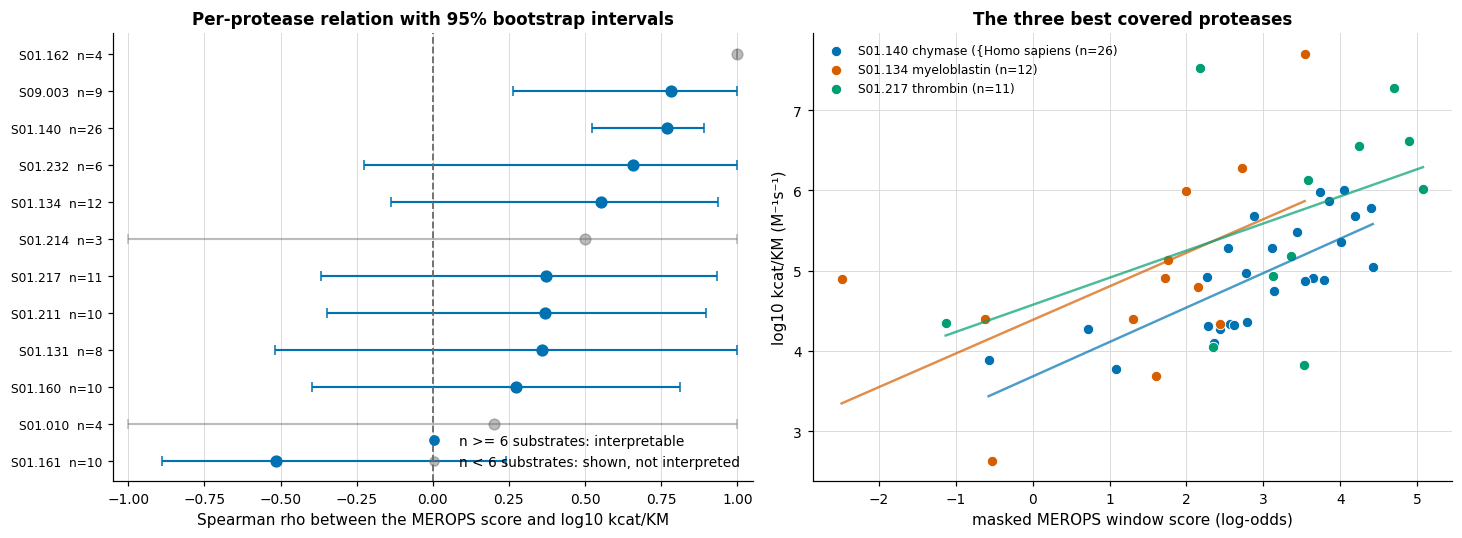

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.0))

ax = axes[0]
ordered = per_protease.sort_values("spearman_rho").reset_index(drop=True)
for position, row in ordered.iterrows():
    colour = common.CATEGORICAL_COLORS[0] if row["interpretable"] else common.NEUTRAL
    ax.errorbar(
        row["spearman_rho"],
        position,
        xerr=[[row["spearman_rho"] - row["ci_low"]], [row["ci_high"] - row["spearman_rho"]]],
        fmt="o",
        color=colour,
        ecolor=colour,
        elinewidth=1.4,
        capsize=3,
        markersize=7,
        alpha=1.0 if row["interpretable"] else 0.45,
    )
ax.axvline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.2)
ax.set_yticks(ordered.index)
ax.set_yticklabels([f"{row.merops_code}  n={row.n_windows}" for row in ordered.itertuples()], fontsize=8)
ax.set_xlim(-1.05, 1.05)
ax.set_xlabel("Spearman rho between the MEROPS score and log10 kcat/KM")
ax.set_title("Per-protease relation with 95% bootstrap intervals")
ax.grid(axis="y", visible=False)
handles = [
    plt.Line2D([], [], marker="o", linestyle="", color=common.CATEGORICAL_COLORS[0],
               label=f"n >= {MIN_INTERPRETABLE_WINDOWS} substrates: interpretable"),
    plt.Line2D([], [], marker="o", linestyle="", color=common.NEUTRAL, alpha=0.45,
               label=f"n < {MIN_INTERPRETABLE_WINDOWS} substrates: shown, not interpreted"),
]
ax.legend(handles=handles, loc="lower right")

## The three best covered proteases keep one colour each; adding more series than
## the palette holds would force a repeat, which makes identity ambiguous.
ax = axes[1]
focus_codes = per_protease.nlargest(3, "n_windows")["merops_code"].tolist()
focus = usable[usable["merops_code"].isin(focus_codes)]
for index, code in enumerate(focus_codes):
    group = focus[focus["merops_code"] == code].drop_duplicates(subset="substrate_sequence")
    ax.scatter(
        group["merops_score"],
        group["log10_kcat_over_km"],
        s=46,
        color=common.CATEGORICAL_COLORS[index],
        edgecolor="white",
        linewidth=0.6,
        label=f"{code} {names.get(code, '')[:22]} (n={len(group)})",
    )
    if len(group) >= 6:
        fit = np.polyfit(group["merops_score"], group["log10_kcat_over_km"], 1)
        grid = np.linspace(group["merops_score"].min(), group["merops_score"].max(), 20)
        ax.plot(grid, np.polyval(fit, grid), color=common.CATEGORICAL_COLORS[index], linewidth=1.6, alpha=0.7)
ax.set_xlabel("masked MEROPS window score (log-odds)")
ax.set_ylabel("log10 kcat/KM (M⁻¹s⁻¹)")
ax.set_title("The three best covered proteases")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Provenance**

BRENDA 2026.1 was extracted by `assets/scripts/downloads/serum_proteolysis_calibration/ingest_brenda.py` into `data/serum_proteolysis_calibration/processed/kinetics/brenda_serum_proteases.parquet`; MEROPS *Substrate_search* 2023 supplies `data/merops/34_homo_sapiens/matrices_logprob.npy` and `codes.json`. Code cells 7–13 keep numeric human rows with a parsed substrate, resolve or select a bond, match direct `kcat_km_value` or publication/protein-matched kcat and Km, then aggregate within `(MEROPS code, substrate sequence)`. BRENDA's 1/(mM·s) becomes 1/(M·s) after multiplication by 1,000; plotted labels use log10 of that value. One plotted protease statistic is computed over substrates, not over independent enzymes or serum assays. Inspect `results/2_01_merops_vs_kinetics_per_protease.csv`, `results/0_15_assembly_losses.csv`, and the `pmids`/`protein_ids` fields in the Parquet source for row lineage. The restricted assay-condition and mutant policy are documented in `0_11` and `_analysis_common.py`.

> **Caveat.** For a FRET/quenched substrate with no resolved cleavage bond, `0_15_analysis_datasets.ipynb` cell 6 selects the maximum MEROPS score over admissible bonds (`argmax`). This selected maximum is a model-derived statistic, not a measured cut site; it can rise with peptide length and a sharper matrix even without better prediction. Report MEROPS–kinetics associations separately for `reporter` (known bond) and `quenched` (selected bond) conventions. Rows sharing one BRENDA measurement across MEROPS codes are dependent (`shares_measurements_with_n_codes`), so nominal N and permutation significance may be optimistic.


## Pooled relation

No single protease here has enough substrates to settle the question on its
own. The pooled statistic asks the weaker but answerable question: **is the
relation present in common across enzymes?**

Both quantities are centred within protease before pooling, that is, each
protease's own mean is subtracted from its scores and from its measurements.
Without that step the comparison would be dominated by the fact that different
enzymes work at different absolute rates and have differently sharp matrices,
and a correlation could appear purely from those offsets. After centring, only
the within-enzyme ordering remains.

The significance comes from the permutation null described at the top: shuffling
the measurements inside each protease preserves every sample size and every
score distribution and removes only the pairing. If the observed value sits
inside that null distribution, the pooled relation is what chance produces.

In [10]:
pooled = usable.drop_duplicates(subset=["merops_code", "substrate_sequence"]).copy()
pooled = pooled[pooled["merops_code"].isin(per_protease["merops_code"])]
pooled["score_centred"] = pooled.groupby("merops_code")["merops_score"].transform(
    lambda values: values - values.mean()
)
pooled["kinetics_centred"] = pooled.groupby("merops_code")["log10_kcat_over_km"].transform(
    lambda values: values - values.mean()
)
pooled_rho = spearmanr(pooled["score_centred"], pooled["kinetics_centred"]).statistic

## REMARK: Substrates of one protease are not independent observations, so the
## null is built by permuting the measurements within each protease. This keeps
## the per-protease sample sizes and the score distribution intact and destroys
## only the pairing.
permutation_generator = np.random.default_rng(SEED)
null_rho = []
for _ in range(N_BOOTSTRAP):
    shuffled = pooled.copy()
    shuffled["kinetics_centred"] = shuffled.groupby("merops_code")["kinetics_centred"].transform(
        lambda values: permutation_generator.permutation(values.to_numpy())
    )
    null_rho.append(spearmanr(shuffled["score_centred"], shuffled["kinetics_centred"]).statistic)
null_rho = np.array(null_rho)
empirical_p = float((np.abs(null_rho) >= abs(pooled_rho)).mean())

print(f"pooled observations: {len(pooled)} across {pooled['merops_code'].nunique()} proteases")
print(f"within-protease Spearman rho = {pooled_rho:.3f}")
print(f"permutation null: mean {null_rho.mean():.3f}, 95th percentile of |rho| "
      f"{np.percentile(np.abs(null_rho), 95):.3f}")
print(f"empirical two-sided p = {empirical_p:.4f} over {N_BOOTSTRAP} permutations")
print()
print(f"median spread between repeated measurements of one substrate: "
      f"{(replicates['max'] - replicates['min']).median():.2f} log10 units, which bounds "
      "how strong any correlation with these labels can be")

pooled observations: 113 across 12 proteases
within-protease Spearman rho = 0.455
permutation null: mean -0.001, 95th percentile of |rho| 0.197
empirical two-sided p = 0.0000 over 2000 permutations

median spread between repeated measurements of one substrate: 0.85 log10 units, which bounds how strong any correlation with these labels can be


### Reading the two panels below

**Left panel.** Every measured substrate of every protease, after centring.
A point in the upper right is a substrate scored above its enzyme's average and
measured above its enzyme's average; the lower left is the mirror case. Both
support the hypothesis. The line is the direction of the relation.

**Right panel.** The grey histogram is the pooled $\rho$ obtained from 2000
shuffles of the measurements within each protease, which is what this analysis
returns when there is no relation. The vertical line is the value actually
observed. The distance between them is the result; the empirical p-value is the
fraction of the histogram at or beyond that line.

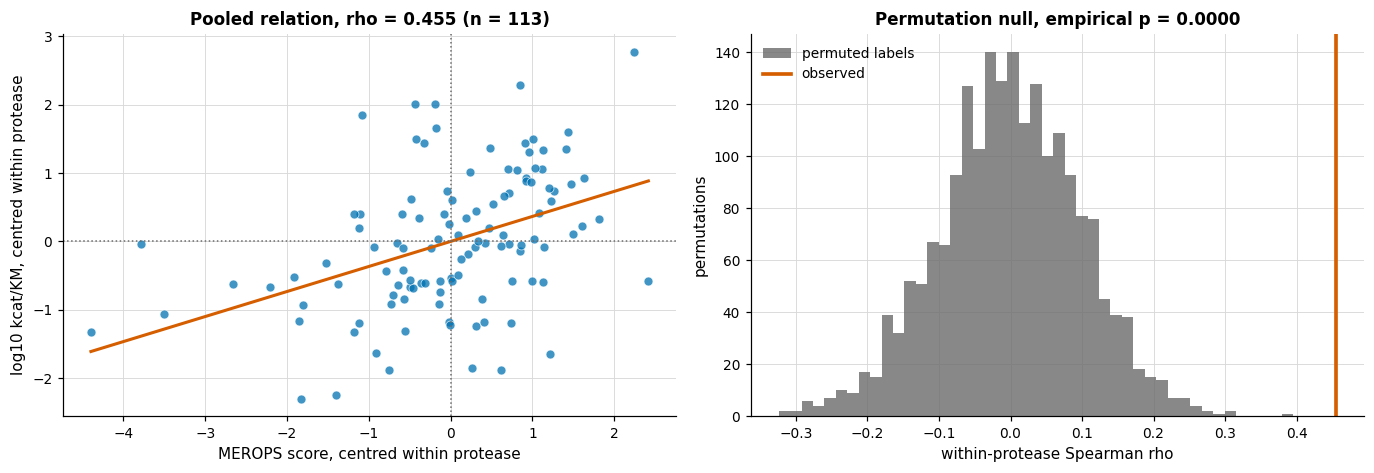

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
ax.scatter(
    pooled["score_centred"],
    pooled["kinetics_centred"],
    s=34,
    color=common.CATEGORICAL_COLORS[0],
    alpha=0.75,
    edgecolor="white",
    linewidth=0.5,
)
fit = np.polyfit(pooled["score_centred"], pooled["kinetics_centred"], 1)
grid = np.linspace(pooled["score_centred"].min(), pooled["score_centred"].max(), 20)
ax.plot(grid, np.polyval(fit, grid), color=common.CATEGORICAL_COLORS[1], linewidth=2)
ax.axhline(0.0, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.axvline(0.0, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.set_xlabel("MEROPS score, centred within protease")
ax.set_ylabel("log10 kcat/KM, centred within protease")
ax.set_title(f"Pooled relation, rho = {pooled_rho:.3f} (n = {len(pooled)})")

ax = axes[1]
ax.hist(null_rho, bins=45, color=common.NEUTRAL, alpha=0.8, label="permuted labels")
ax.axvline(pooled_rho, color=common.CATEGORICAL_COLORS[1], linewidth=2.4, label="observed")
ax.set_xlabel("within-protease Spearman rho")
ax.set_ylabel("permutations")
ax.set_title(f"Permutation null, empirical p = {empirical_p:.4f}")
ax.legend()
fig.tight_layout()
plt.show()

## The DPP4 held-out test

The qPISA dataset is the only set large enough to test generalization rather
than fit.

### The label and its sign

The value is the log2 abundance of a peptide after digestion minus its
abundance in a matched no-enzyme control. A peptide that was cleaved is
**depleted**, so its value is negative. A susceptibility score that works
therefore produces a **negative** correlation with this label. The sign is the
opposite of the BRENDA sections above, where the label was a rate.

### The split

Training and test sets are separated by N-terminal dipeptide context, not by
random row. A random split would put near-identical local contexts on both
sides, and the test would then measure interpolation between seen contexts
rather than transfer to unseen ones.

### What a weak correlation here would and would not mean

The 53 499 peptides are proteome-derived, whereas the BRENDA substrates for the
same enzyme are nine designed chromogenic reporters. A score that works on the
designed set and fails here has not generalized to natural sequences, which is
the population the model is meant for.

In [12]:
qpisa = pd.read_excel(
    common.SERUM_RAW / "dpp4_qpisa" / "PMC11612144" / "44320_2024_71_MOESM2_ESM.xlsx",
    sheet_name="Peptide_Levels_dpf-3_dpp4",
)
qpisa.columns = ["sequence", "status", "dpf3", "dpp4", "control_for_dpf3", "control_for_dpp4"]
qpisa["depletion"] = qpisa["dpp4"] - qpisa["control_for_dpp4"]

DPP4_CODE = "S09.003"
dpp4_matrix, dpp4_dataset, dpp4_cleavages = matrix_for(DPP4_CODE)
dpp4_bond = int(np.flatnonzero(allowed_cut_positions(12, EventGeometry.DIPEPTIDYL_PEPTIDASE))[0])
observable = subsite_observability_mask(12, dpp4_bond)
subsite_rows = np.flatnonzero(observable)
residue_offsets = dpp4_bond + np.array([-3, -2, -1, 0, 1, 2, 3, 4])[observable]

print(f"MEROPS matrix for {DPP4_CODE}: dataset {dpp4_dataset}, {dpp4_cleavages} cleavages")
print(f"observable subsites at the DPP4 bond: "
      f"{[MEROPS_SUBSITES[i] for i in subsite_rows]}")

## Vectorized masked score over the observable subsites
column_of = {residue: column for column, residue in enumerate(MEROPS_AMINO_ACIDS)}
encoded = np.array(
    [[column_of[residue] for residue in sequence[: residue_offsets.max() + 1]] for sequence in qpisa["sequence"]]
)  # (n_peptides, window)
log_odds = specificity_log_odds(dpp4_matrix, background=human_background)  # (P, A)
qpisa["merops_score"] = sum(
    log_odds[row, encoded[:, offset]] for row, offset in zip(subsite_rows, residue_offsets)
)  # (n_peptides,)

qpisa["context"] = qpisa["sequence"].str[:2]
contexts = qpisa["context"].unique()
generator = np.random.default_rng(SEED)
test_contexts = set(generator.choice(contexts, size=int(0.3 * len(contexts)), replace=False))
qpisa["split"] = np.where(qpisa["context"].isin(test_contexts), "test", "train")

print()
print(qpisa.groupby("split").agg(peptides=("sequence", "size"), contexts=("context", "nunique")).to_string())

train = qpisa.query("split == 'train'")
test = qpisa.query("split == 'test'")
merops_rho = spearmanr(test["merops_score"], test["depletion"]).statistic
print()
print("sign convention: a cleaved peptide is depleted, so a susceptibility score "
      "that works correlates negatively with depletion")
print(f"MEROPS score vs depletion, held-out contexts: rho = {merops_rho:.3f}")
print(f"MEROPS score vs depletion, training contexts: "
      f"{spearmanr(train['merops_score'], train['depletion']).statistic:.3f}")

MEROPS matrix for S09.003: dataset 34, 29 cleavages
observable subsites at the DPP4 bond: ['P2', 'P1', 'P1p', 'P2p', 'P3p', 'P4p']

       peptides  contexts
split                    
test      14479       118
train     39020       278

sign convention: a cleaved peptide is depleted, so a susceptibility score that works correlates negatively with depletion
MEROPS score vs depletion, held-out contexts: rho = -0.159
MEROPS score vs depletion, training contexts: -0.130


### Ceiling of a window-only model

A ridge regression on the one-hot encoding of the same subsites is refitted on
the training contexts and evaluated on the same held-out contexts.

The comparison is controlled: the refitted model sees exactly the residues the
MEROPS score sees, at exactly the same subsites, and is tested on exactly the
same peptides. It differs only in where its coefficients came from — this
dataset rather than the MEROPS cleavage records.

Its correlation is therefore the ceiling of what any window-only model can
reach on these data. The distance between that ceiling and the MEROPS score is
signal the representation carries and this matrix fails to extract; anything
missing above the ceiling is beyond a window model altogether.

The refitted model predicts the depletion value itself, so its correlation with
depletion is positive, while the MEROPS score predicts susceptibility and is
expected to be negative. Only the magnitudes are comparable.

In [13]:
def one_hot(frame: pd.DataFrame) -> np.ndarray:
    """Encode the observable subsites of each peptide as indicator variables.

    :param frame: Peptide table with a ``sequence`` column.
    :return: Indicator matrix, shape ``(n_peptides, len(subsites) * A)``.
    """

    rows = np.zeros((len(frame), len(residue_offsets) * len(MEROPS_AMINO_ACIDS)))
    sequences = frame["sequence"].to_numpy()
    for position, offset in enumerate(residue_offsets):
        columns = np.array([column_of[sequence[offset]] for sequence in sequences])
        rows[np.arange(len(frame)), position * len(MEROPS_AMINO_ACIDS) + columns] = 1.0
    return rows


ridge = Ridge(alpha=1.0).fit(one_hot(train), train["depletion"].to_numpy())
ridge_rho = spearmanr(ridge.predict(one_hot(test)), test["depletion"]).statistic

## The refitted model predicts the depletion value itself, so its correlation with
## depletion is positive, while the MEROPS score predicts susceptibility and is
## expected to be negative. The comparable quantity is the magnitude.
print(f"refitted window model, held-out contexts: rho = {ridge_rho:+.3f} (|rho| = {abs(ridge_rho):.3f})")
print(f"MEROPS score, same contexts:              rho = {merops_rho:+.3f} (|rho| = {abs(merops_rho):.3f})")
print()
print(f"signal the window representation carries but this matrix does not extract: "
      f"{abs(ridge_rho) - abs(merops_rho):.3f} in |rho|")

refitted window model, held-out contexts: rho = +0.412 (|rho| = 0.412)
MEROPS score, same contexts:              rho = -0.159 (|rho| = 0.159)

signal the window representation carries but this matrix does not extract: 0.254 in |rho|


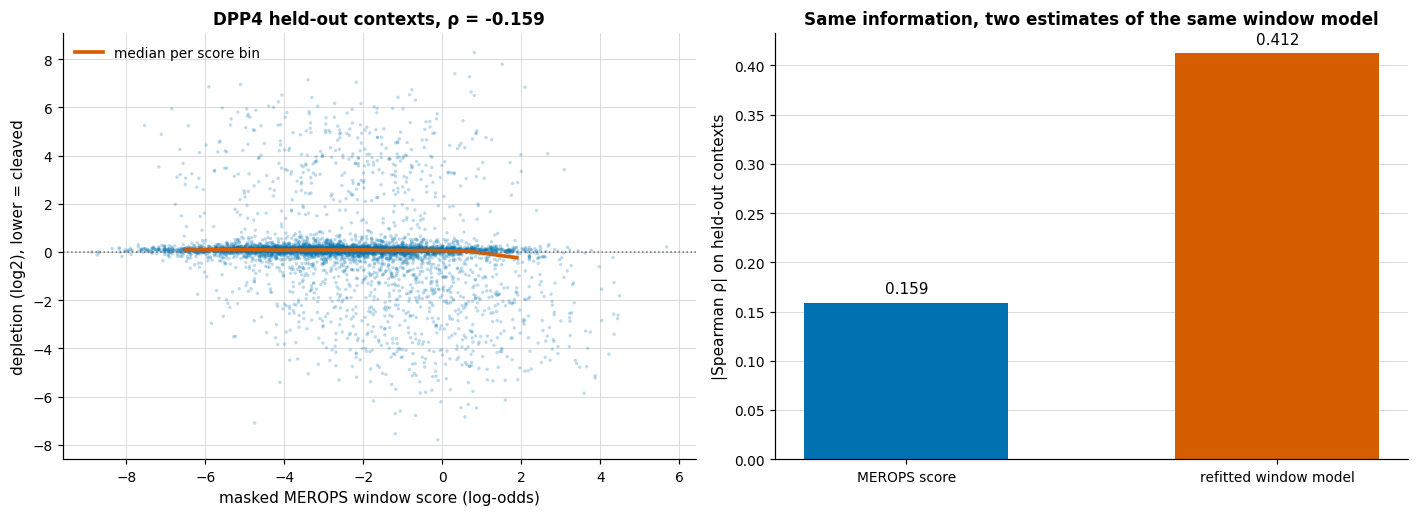

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

ax = axes[0]
sample = test.sample(n=min(6000, len(test)), random_state=SEED)
ax.scatter(
    sample["merops_score"],
    sample["depletion"],
    s=5,
    alpha=0.25,
    color=common.CATEGORICAL_COLORS[0],
    edgecolor="none",
)
edges = np.quantile(test["merops_score"], np.linspace(0, 1, 21))
bin_index = np.clip(np.searchsorted(edges, test["merops_score"], side="right") - 1, 0, len(edges) - 2)
profile = (
    test.assign(bin_index=bin_index)
    .groupby("bin_index")
    .agg(score=("merops_score", "median"), depletion=("depletion", "median"))
)
ax.plot(
    profile["score"],
    profile["depletion"],
    color=common.CATEGORICAL_COLORS[1],
    linewidth=2.4,
    label="median per score bin",
)
ax.axhline(0.0, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.set_xlabel("masked MEROPS window score (log-odds)")
ax.set_ylabel("depletion (log2), lower = cleaved")
ax.set_title(f"DPP4 held-out contexts, ρ = {merops_rho:.3f}")
ax.legend()

ax = axes[1]
comparison = pd.DataFrame(
    {
        "model": ["MEROPS score", "refitted window model"],
        "rho": [abs(merops_rho), abs(ridge_rho)],
    }
)
bars = ax.bar(
    comparison["model"],
    comparison["rho"],
    color=[common.CATEGORICAL_COLORS[0], common.CATEGORICAL_COLORS[1]],
    width=0.55,
)
for bar, value in zip(bars, comparison["rho"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.3f}", ha="center", fontsize=10)
ax.set_ylabel("|Spearman ρ| on held-out contexts")
ax.set_title("Same information, two estimates of the same window model")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

**Provenance**

The DPP4 holdout uses Gudipati et al. 2024 Dataset EV1, `data/serum_proteolysis_calibration/raw/dpp4_qpisa/PMC11612144/44320_2024_71_MOESM2_ESM.xlsx`, acquired by `download_pmc_supplements.py`; the local paper is `report/articles/2024_10_28_Gudipati_Deep_quantification_of_substrate_turnover_defines_protease_subsite_cooperativity.pdf`. One observation is one `Tryptic+` input peptide with a four-hour control-minus-treated log2 intensity; `results/0_06_funnel.csv` records 43,314 retained inputs and 10,185 product rows held out. Code cells 22–25 compare that endpoint with a fixed MEROPS score and a fitted window-only ceiling. The assay endpoint is not kcat/Km and cannot set an absolute serum time axis.


## Results

The per-protease table and the DPP4 held-out comparison are written for the
report and are the input to `2_02_holdout_baseline.ipynb`, which decides
each protease individually.

What this notebook establishes is the panel-level statement: whether the
relation exists at all. What it does not establish is that any individual
protease can be relied on, which needs the per-protease battery.

In [15]:
holdout = pd.DataFrame(
    [
        {
            "protease": DPP4_CODE,
            "dataset": "dpp4_qpisa_PXD042089",
            "label": "log2 depletion versus no-enzyme control",
            "split": "held-out N-terminal dipeptide contexts",
            "n_train": len(train),
            "n_test": len(test),
            "n_test_contexts": test["context"].nunique(),
            "merops_rho_train": float(spearmanr(train["merops_score"], train["depletion"]).statistic),
            "merops_rho_test": float(merops_rho),
            "refit_window_model_rho_test": float(ridge_rho),
            "merops_cleavages": dpp4_cleavages,
        }
    ]
)
per_protease["pooled_within_protease_rho"] = pooled_rho
per_protease["pooled_permutation_p"] = empirical_p
common.save_result(per_protease, "2_01_merops_vs_kinetics_per_protease.csv")
common.save_result(holdout, "2_01_dpp4_holdout.csv")

significant = interpretable[interpretable["ci_low"] > 0]
print(f"BRENDA: {len(per_protease)} proteases tested, {len(interpretable)} with at least "
      f"{MIN_INTERPRETABLE_WINDOWS} windows, {len(significant)} of those with an interval above zero")
if len(significant):
    print(significant[["merops_code", "name", "n_windows", "spearman_rho", "ci_low", "ci_high"]].round(3).to_string(index=False))
print()
print(f"pooled within-protease rho = {pooled_rho:.3f}, permutation p = {empirical_p:.4f}")
print(f"DPP4 held out: MEROPS |rho| = {abs(merops_rho):.3f}, refitted window model |rho| = {abs(ridge_rho):.3f}")
holdout.T

BRENDA: 12 proteases tested, 9 with at least 6 windows, 2 of those with an interval above zero
merops_code                                name  n_windows  spearman_rho  ci_low  ci_high
    S01.140       chymase ({Homo sapiens}-type)         26         0.769   0.523    0.889
    S09.003 dipeptidyl-peptidase IV (eukaryote)          9         0.783   0.263    1.000

pooled within-protease rho = 0.455, permutation p = 0.0000
DPP4 held out: MEROPS |rho| = 0.159, refitted window model |rho| = 0.412


,0
protease,S09.003
dataset,dpp4_qpisa_PXD042089
label,log2 depletion versus no-enzyme control
split,held-out N-terminal dipeptide contexts
n_train,39020
n_test,14479
n_test_contexts,118
merops_rho_train,-0.130147
merops_rho_test,-0.158648
refit_window_model_rho_test,0.412221
